<a href="https://colab.research.google.com/github/aboelenin-tech/marketing-subscribction/blob/main/session8task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [7]:
df.isnull()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
45207,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
45208,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
45209,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


In [10]:
df["y"].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


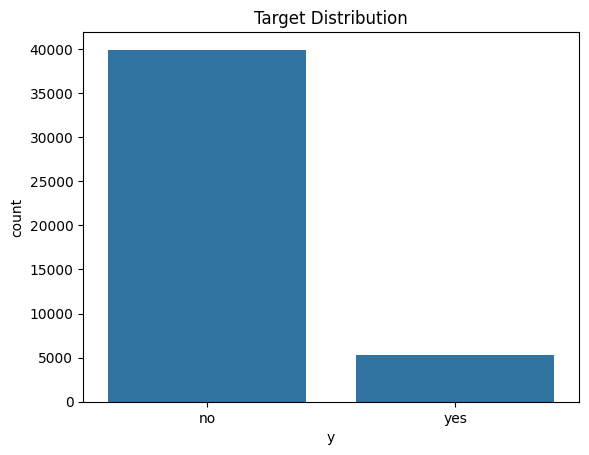

In [11]:
sns.countplot(data=df, x="y")
plt.title("Target Distribution")
plt.show()

In [12]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

 marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

 education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

 default
default
no     44396
yes      815
Name: count, dtype: int64

 housing
housing
yes    25130
no     20081
Name: count, dtype: int64

 loan
loan
no     37967
yes     7244
Name: count, dtype: int64

 contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

 month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)


Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [14]:
X = df.drop("y", axis=1)
y = df["y"]

In [15]:
y = y.map({
    "no": 0,
    "yes": 1
})

In [16]:
y.value_counts()

,count
y,
0,39922
1,5289


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(include=np.number).columns
print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Categorical:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

Numerical:
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])
dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.8737144752847507
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.46      0.47      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.87      0.87      0.87      9043



In [21]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42
    ))
])
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_bagging))

Accuracy: 0.9051199823067566


Random Forest Accuracy: 0.9069998894172288
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.67      0.40      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.90      0.91      0.90      9043



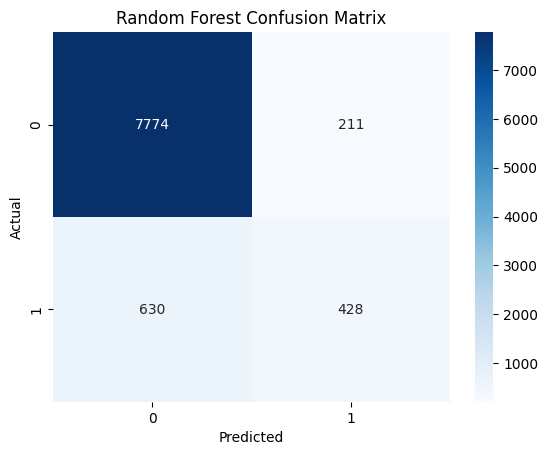

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

AdaBoost Accuracy: 0.8976003538648678
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.62      0.33      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



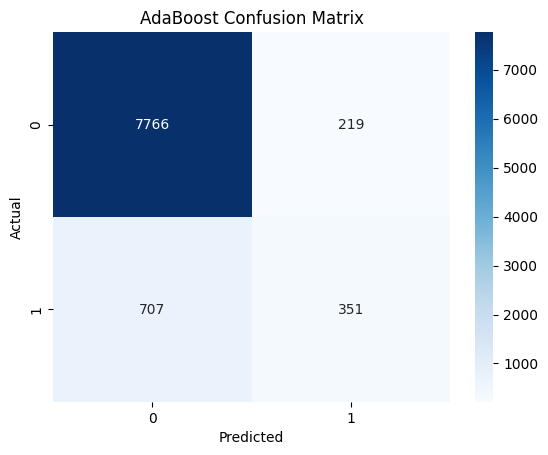

In [23]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=100,
        random_state=42
    ))
])

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print(
    "AdaBoost Accuracy:",
    accuracy_score(y_test, y_pred_ada)
)

print(
    classification_report(
        y_test,
        y_pred_ada
    )
)

cm = confusion_matrix(
    y_test,
    y_pred_ada
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")

plt.show()

XGBoost Accuracy: 0.9042353201371226
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.38      0.48      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



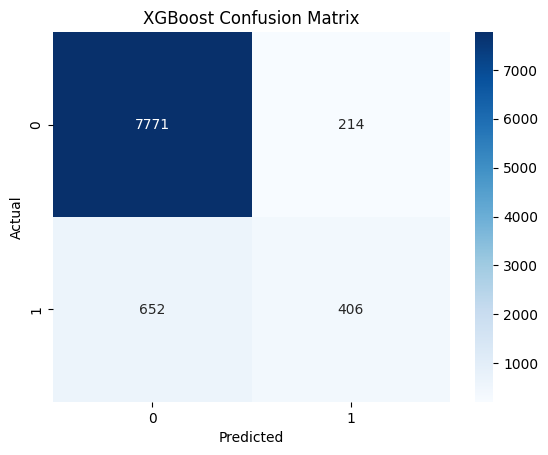

In [24]:
from xgboost import XGBClassifier


xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("\nTest Set Results:")
print(classification_report(y_test, y_pred_best_rf))

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Best CV F1:
0.4956113646635929

Test Set Results:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.67      0.40      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043



In [22]:
# ## Conclusion


# This project applied several ensemble learning techniques — Bagging, Random Forest, AdaBoost, and XGBoost — to predict whether a bank client would subscribe to a term deposit, using the Bank Marketing dataset (45,211 records, 17 features). A single Decision Tree served as the baseline, achieving 87.4% accuracy but a weak F1-score of 0.47 for the minority "yes" class, reflecting the dataset's class imbalance (88.3% "no" vs. 11.7% "yes").

# Ensemble methods consistently outperformed the single tree. Random Forest achieved the best overall balance, with 90.7% accuracy and an F1-score of 0.50 on the positive class, followed closely by XGBoost (90.4%, F1 0.48) and Bagging (90.5%). AdaBoost underperformed slightly relative to the other ensembles (89.8%, F1 0.43), likely due to its sensitivity to noisy or imbalanced data with weak (depth-1) learners.

# Hyperparameter tuning via GridSearchCV on the Random Forest model confirmed the default configuration was already near-optimal, with the best cross-validated F1-score (0.496) matching the untuned model's test performance. This suggests further gains would likely come not from tuning tree parameters further, but from addressing class imbalance directly — e.g., via SMOTE/undersampling, class-weighting, or threshold adjustment — since all models struggled more with recall on the minority "yes" class than with overall accuracy.

# Overall, ensemble methods, particularly Random Forest, proved more robust and better suited to this imbalanced classification problem than a single decision tree, though there remains meaningful room to improve minority-class detection.